## Imports

In [1]:
import math , random
import torch
import torch.nn as nn
import torch.functional as F
from PIL import ImageDraw , Image
from matplotlib import pyplot as plt
import numpy as np

In [18]:
# some constants
IMG_SIZE = 32
EMBEDDED_DIM = 64
ATTENTION_HEADS = 8
EPOCHS = 10
BATCH_SIZE = 4
LR = 3e-4
TEMPERATURE = 0.07

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

## Synthetic dataset properties.

In [4]:
colors = ['red' , 'green' , 'blue' , 'yellow' , 'purple' , 'orange' , 'pink' , 'brown' , 'gray']
shapes = ['square' , 'circle' , 'triangle']
positions = ['left' , 'center' , 'right' , 'top' , 'bottom' , 'top-left' , 'top-right' , 'bottom-left' , 'bottom-right']

## Drawing image shapes

In [5]:
def draw_sample(color , shape , position , img_size = IMG_SIZE):
    img = Image.new('RGB' ,(img_size , img_size) , 'white')
    draw = ImageDraw.Draw(img)

    margin = 6
    h = w = img_size -2*margin

    # calculate x coordinates
    if 'left' in position or 'top-left' in position or 'bottom-left' in position:
        x0 = margin
        x1 = margin + w // 2
    elif 'right' in position or 'top-right' in position or 'bottom-right' in position:
        x0 = margin + w // 2
        x1 = img_size - margin
    else:
        x0 = margin + w // 4
        x1 = margin + 3 * w // 4

    # calculate y coordinates
    if 'top' in position or 'top-left' in position or 'top-right' in position:
        y0 = margin
        y1 = margin + h // 2
    elif 'bottom' in position or 'bottom-left' in position or 'bottom-right' in position:
        y0 = margin + h // 2
        y1 = img_size - margin
    else:
        y0 = margin + h // 4
        y1 = margin + 3 * h // 4

    # select shape
    if shape == 'square':
        draw.rectangle([x0,y0,x1,y1] ,fill = color , outline = 'black')
    elif shape == 'circle':
        draw.ellipse([x0, y0, x1, y1], fill=color, outline='black')
    else: # triangle
        draw.polygon([(x0 + (x1 - x0) // 2 , y0) , (x0 , y1) , (x1 , y1)] , fill = color , outline = 'black')
    return img

## Class for building the dataset(image and caption)

In [8]:
class ShapesDataset():
    def __init__(self):
        self.images = []
        self.captions = []

        # generate all combinations
        for c in colors:
            for s in shapes:
                for p in positions:
                    img = draw_sample(c, s, p)
                    cap = f"{c} {s} {p}"

                    self.images.append(
                        torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255.0
                    )
                    self.captions.append(cap)

        # build vocab AFTER captions are ready
        self.vocab, self.word2index = self.build_vocab(self.captions)

    def build_vocab(self, texts):
        words = sorted({w for t in texts for w in t.split()})
        vocab = ['[CLS]'] + words
        word2index = {w: i for i, w in enumerate(vocab)}
        return vocab, word2index

    def encode_text(self, text):
        tokens = [self.word2index['[CLS]']] + \
                 [self.word2index[w] for w in text.split()]
        return torch.tensor(tokens, dtype=torch.long)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        return (
            self.images[index],
            self.encode_text(self.captions[index]),
            self.captions[index]
        )

In [9]:
dataset = ShapesDataset()
VOCAB_SIZE = len(dataset.vocab)
VOCAB_SIZE

22

## Train and validation data split

In [10]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

In [11]:
train_ds, val_ds = torch.utils.data.random_split(
    dataset,
    [train_size, val_size]
)

## Data Loader

In [12]:
from torch.utils.data import DataLoader
train_loader = DataLoader(
    train_ds,
    batch_size = BATCH_SIZE,
    shuffle = True
)
val_loader = DataLoader(
    val_ds,
    batch_size = BATCH_SIZE,
    shuffle = True
)

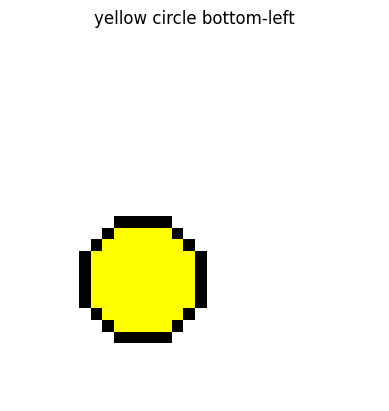

In [11]:
# a sample image
images, tokens, captions = next(iter(train_loader))
# take first sample in batch
img = images[0]
img = img.permute(1, 2, 0).numpy()

plt.imshow(img)
plt.title(captions[0])
plt.axis("off")
plt.show()

## Image Encoder

In [13]:
class ImageEncoder(nn.Module):
    def __init__(self , embed_dim = EMBEDDED_DIM):
        super().__init__()
        self.convLayers = nn.Sequential(
            nn.Conv2d(3 , 32 , 3 , 2 , 1),
            nn.ReLU(),
            nn.Conv2d(32 , 64 , 3 , 2 , 1),
            nn.ReLU(),
            nn.Conv2d(64 , 128 , 3 , 2 , 1),
            nn.ReLU(),
            nn.Conv2d(128 , 256 , 3 , 2 , 1),
            nn.ReLU()
        )

        self.projection = nn.Linear(256 , embed_dim)
        self.layernorm1 = nn.LayerNorm(embed_dim)

    def forward(self , x):
        x = self.convLayers(x)
        x = x.mean(dim = [2 , 3]) # global avg pooling
        x = self.projection(x)
        x = F.normalize(self.layernorm1(x) , dim = -1)
        return x

## Text Encoder

In [19]:
class TextEncoder(nn.Module):
    def __init__(self ,
        embed_dim = EMBEDDED_DIM,
        num_head = ATTENTION_HEADS,
        vocab_size = VOCAB_SIZE,
        context_window = 4
    ):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size , embed_dim)
        self.position_embedding = nn.Embedding(context_window , embed_dim)
        self.multiHeadAttention = nn.MultiheadAttention(embed_dim , num_head , batch_first = True)
        self.projection = nn.Linear(embed_dim , embed_dim)
        self.layerNorm = nn.LayerNorm(embed_dim)

    def forward(self , tokens):
        N , L = tokens.shape
        position_embedding_ids = torch.arange(
            L , device = tokens.device
        ).unsqueeze(0).expand(N , L)

        tokens_embedding_vectors = self.token_embedding(tokens)
        position_embedding_vectors = self.position_embedding(position_embedding_ids)

        final_embedding = tokens_embedding_vectors + position_embedding_vectors
        
        context_vectors = self.multiHeadAttention(
            final_embedding , final_embedding , final_embedding # Q , K , V
        )[0]

        final_token = context_vectors[ : , 0] # use only the [CLS] context vector
        projection = self.projection(final_token)
        output = F.normalize(self.layerNorm(projection) , dim = -1)
        return output

### CLIP Loss

In [15]:
def clip_loss(img_emb , text_emb , temperature = TEMPERATURE):
    logits = img_emb @ text_emb.T / temperature
    targets = torch.arange(img_emb.size(0) , device = img_emb.device)
    loss_i = F.cross_entropy(logits , targets)
    loss_t = F.cross_entropy(logits.T , targets)
    return (loss_i + loss_t)/2.0

### Model, data, optimizer

In [20]:
img_encoder = ImageEncoder().to(device)
text_encoder = TextEncoder().to(device)
params = list(img_encoder.parameters()) + list(text_encoder.parameters())
optimizer = torch.optim.AdamW(params = params , lr = LR)

In [21]:
def show_image(t , title = None):
    img = (t.permute(1 , 2 , 0).numpy()*255).astype(np.uint8)
    plt.figure(figsize = (2.2 , 2.2))
    plt.axis('off')
    if title:
        plt.title(title)
    plt.imshow(img)
    plt.show()